<a href="https://colab.research.google.com/github/luwnvictor/HospitalTech/blob/main/AnaliseDeDados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏥 HospitalTech — Sistema de Gestão Hospitalar
**Projeto Integrador · Análise e Desenvolvimento de Sistemas — UNINOVE**

| Disciplina | Contribuição |
|---|---|
| Análise de Dados | ETL, KPIs, estatística descritiva, correlação |
| Pesquisa Operacional | Eficiência de escala médica e otimização |
| Gerência de Projetos | Métricas de acompanhamento de metas SMART |
| Segurança da Informação | Anonimização e conformidade LGPD (estrutura) |

---


  HOSPITALTECH — PAINEL DE KPIs OPERACIONAIS

  KPI 1 — Tempo Médio de Espera
          Atual  : 78.0 min
          Meta   : 62.4 min  (-20% em 6 meses)
          Status : ACIMA DA META

  KPI 2 — Taxa de Ocupação Crítica (>=90%)
          Taxa   : 15.5%  (26 horas em 168)
          Status : ACIMA DE 12%

  KPI 3 — Razão Pacientes/Médico
          Média  : 4.86 pac/médico
          Pico   : 38.0 pac/médico
          Status : PRESSÃO ALTA

  KPI 4 — Correlação Demanda x Espera
          Pearson r : 0.091
          p-valor   : 0.24
          Interpretação: Fraca — gargalo NÃO é volume, mas alocação de escala

  KPI 5 — SLA Violado (espera = 120 min)
          Taxa   : 13.1%  (22 horas em 168)
          Status : ACEITÁVEL


  ESTATÍSTICA DESCRITIVA — Tempo de Espera (min)
---------------------------------------------
  count       : 168.0
  mean        : 78.0
  std         : 31.1
  min         : 7.0
  25%         : 56.2
  50%         : 74.0
  75%         : 110.0
  max         : 120.0
  As

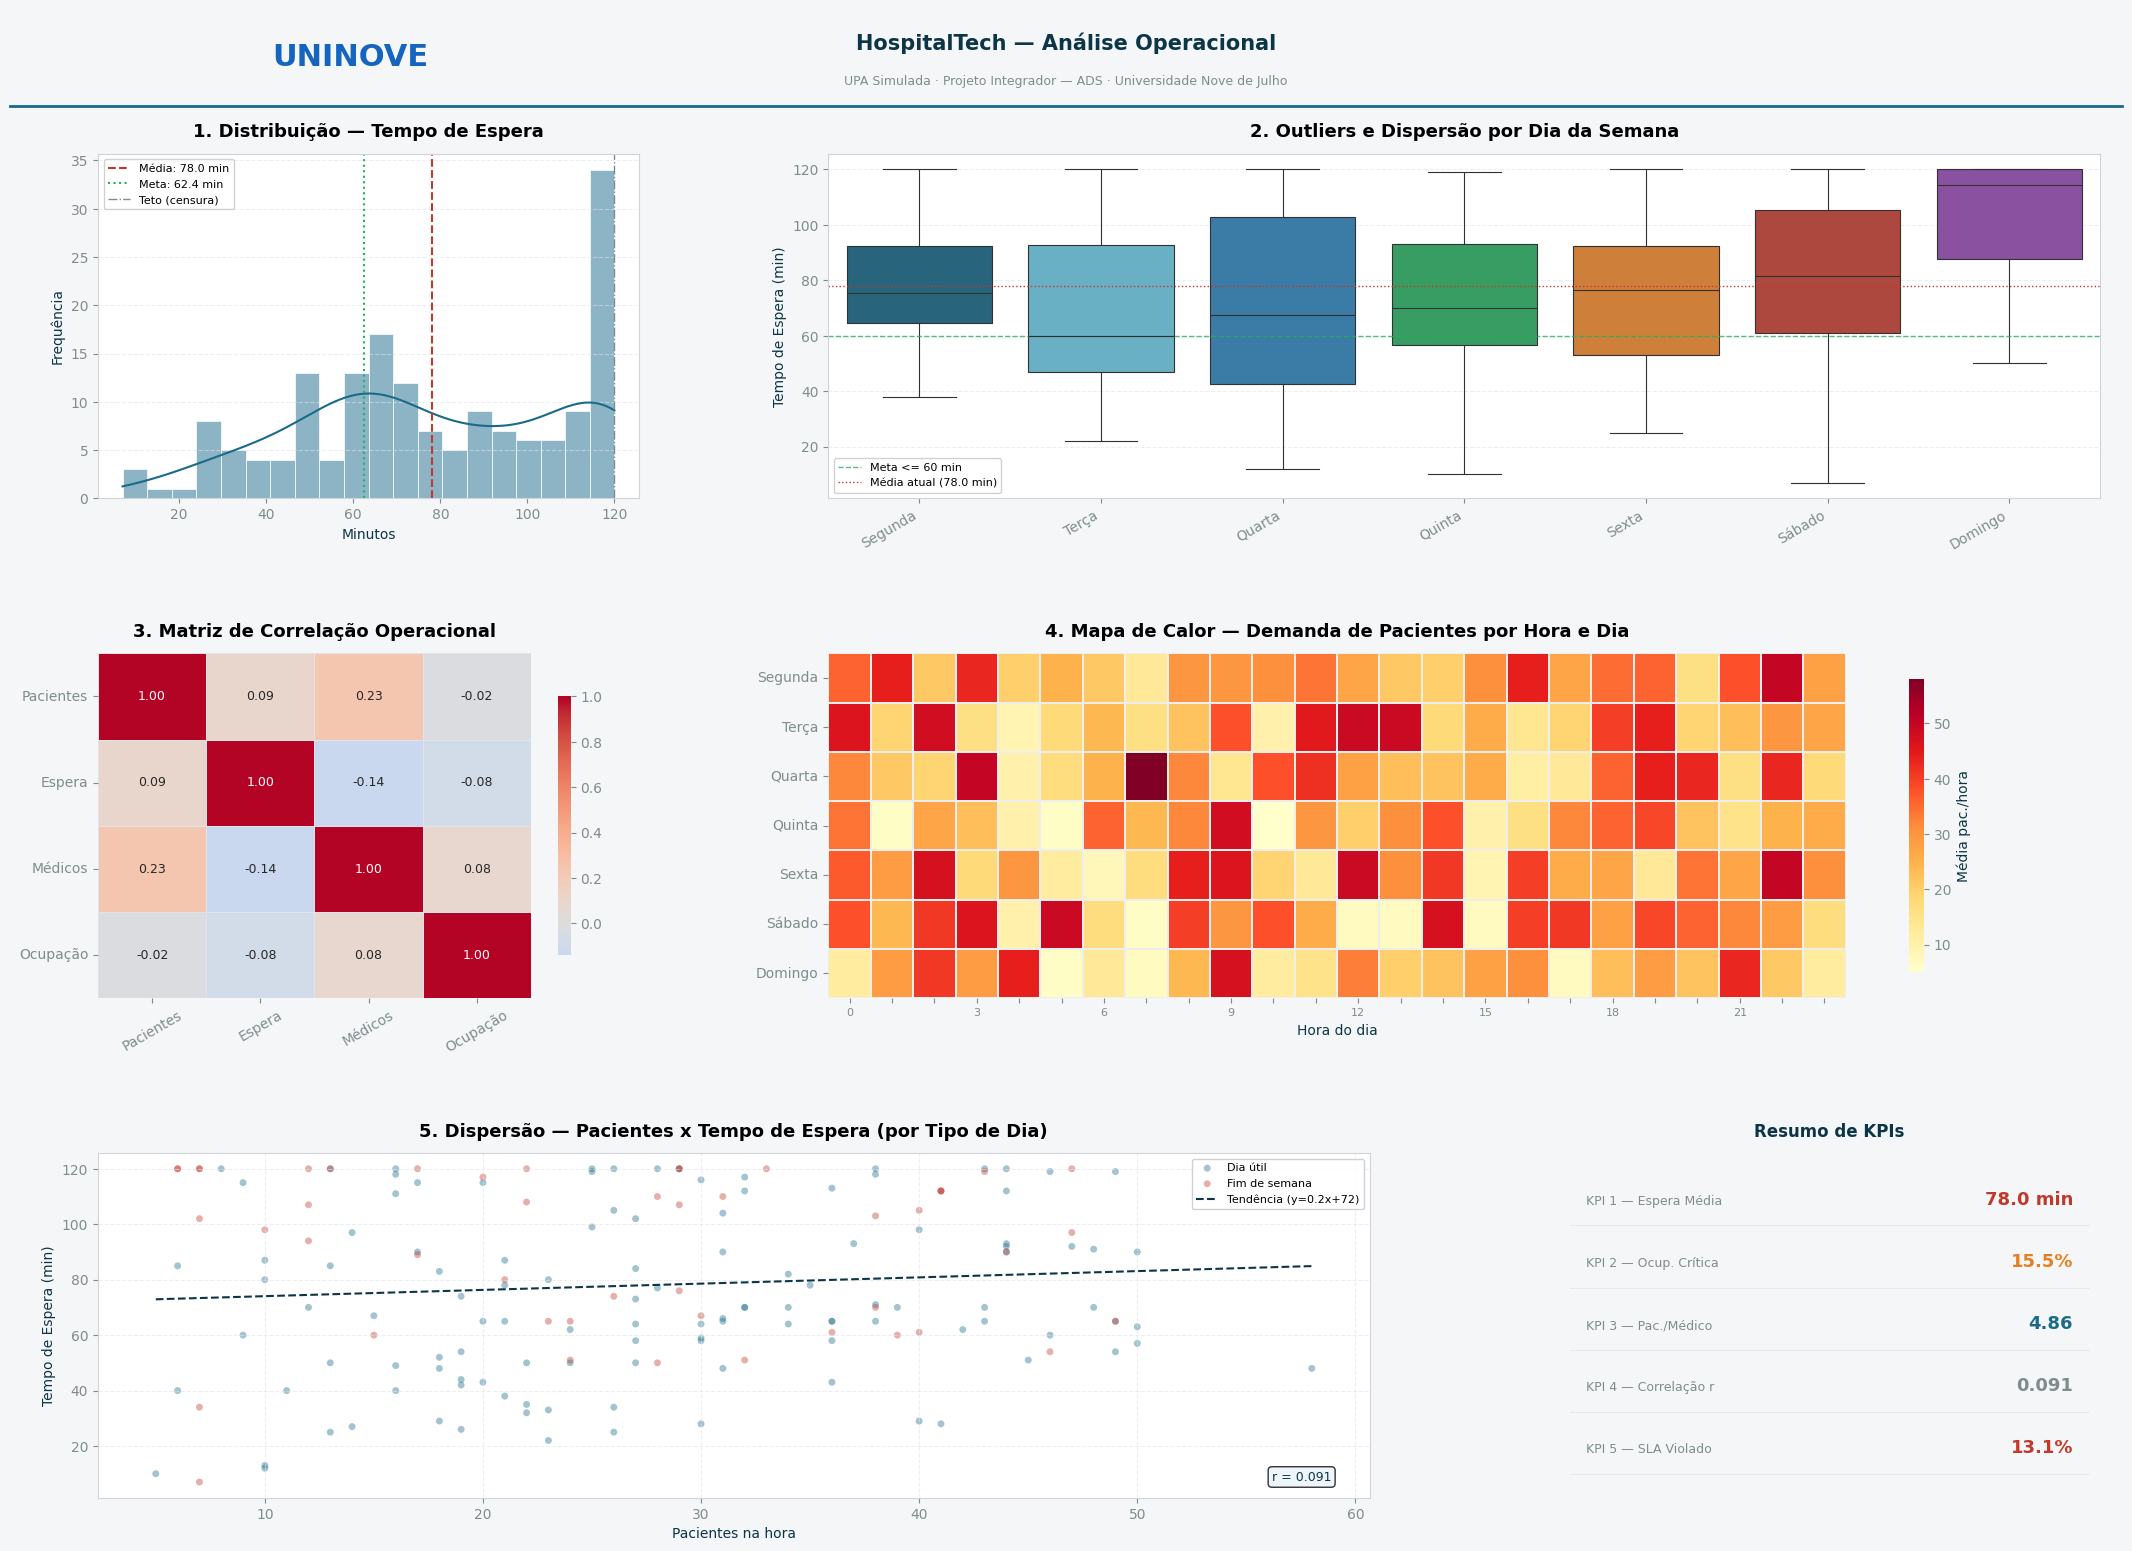


  ANÁLISE CRÍTICA — GARGALOS E RECOMENDAÇÕES

  Top 5 horários com maior espera média:
    17h -> 95.6 min
    09h -> 93.6 min
    23h -> 92.4 min
    02h -> 91.1 min
    19h -> 89.3 min

  Pressão média (pac/médico) por turno:
    Tarde (12-17h): 6.62 <- PICO CRÍTICO
    Noite (18-23h): 6.36
    Madrugada (0-5h): 6.36
    Manhã (6-11h): 5.94

  Espera média — Dias úteis    : 72.7 min
  Espera média — Fim de semana : 91.3 min
  Diferença                    : +18.6 min nos fins de semana

  CONCLUSÃO:
  O maior gargalo operacional é a escala médica desalinhada com a demanda.
  A correlação de Pearson r=0.091 (próxima de 0) confirma que
  o volume de pacientes explica menos de 1% da variância no tempo de espera,
  evidenciando que o problema está na ALOCAÇÃO DE RECURSOS, não na demanda.

  O Heatmap (Gráfico 4) evidencia picos concentrados entre 08h-14h e após 20h,
  exatamente os turnos com maior razão pacientes/médico (KPI 3 = 4.86).

  O KPI 5 indica que 13.1% das horas registram esp

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.image as mpimg
import seaborn as sns
import scipy.stats as stats
import warnings
import os

warnings.filterwarnings("ignore")

# Define LOGO_PATH to avoid NameError if not provided
LOGO_PATH = None

# ── Paleta de cores ───────────────────────────────────────────────────────────
PALETTE = {
    "azul_escuro": "#0C3547",
    "azul_medio":  "#1A6B8A",
    "azul_claro":  "#5BB8D4",
    "vermelho":    "#C0392B",
    "laranja":     "#E67E22",
    "verde":       "#27AE60",
    "cinza":       "#7F8C8D",
    "fundo":       "#F4F6F8",
    "branco":      "#FFFFFF",
}

plt.rcParams.update({
    "figure.facecolor":  PALETTE["fundo"],
    "axes.facecolor":    PALETTE["branco"],
    "axes.edgecolor":    "#D0D3D8",
    "axes.labelcolor":   PALETTE["azul_escuro"],
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.titlepad":     12,
    "xtick.color":       PALETTE["cinza"],
    "ytick.color":       PALETTE["cinza"],
    "font.family":       "DejaVu Sans",
    "grid.color":        "#E0E3E8",
    "grid.linestyle":    "--",
    "grid.alpha":        0.6,
    "legend.framealpha": 0.9,
    "legend.fontsize":   9,
})

DIAS_SEMANA = ["Segunda", "Terça", "Quarta", "Quinta", "Sexta", "Sábado", "Domingo"]



# =============================================================================
# BLOCO 2 — ETL (EXTRAÇÃO, TRANSFORMAÇÃO E CARGA)
# =============================================================================


pacientes_raw = [
    [36,44,21,43,20,25,21,13,30,30,31,34,27,21,20,31,44,27,35,36,16,38,50,28],
    [46,19,48,16, 9,18,24,16,22,38,10,45,49,49,18,26,14,19,40,44,19,23,30,27],
    [32,21,19,50,10,17,25,58,32,14,38,42,28,23,22,26,11,13,36,44,43,16,43,18],
    [34, 6,27,23,10, 6,36,24,32,48, 5,30,20,31,38,10,16,32,36,39,22,15,25,26],
    [37,29,47,18,30,12, 8,17,44,46,19,13,49,31,41, 9,40,26,27,13,34,27,50,31],
    [38,24,41,46,10,49,17, 6,40,30,38,26, 7, 7,47, 7,40,41,28,39,36,32,29,17],
    [12,29,41,29,44, 6,13, 7,24,47,12,15,33,20,22,28,31, 7,23,29,22,43,21,12],
]
espera_raw = [
    [65,93,87,65,65,120,38,50,116,64,65,82,58,78,43,104,92,73,78,58,111,65,90,120],
    [60,44,91,120,60,29,50,118,50,118,80,51,119,65,48,34,27,54,98,112,74,22,28,64],
    [70,65,42,57,12,115,99,48,117,97,120,62,77,80,35,25,40,120,43,120,70,40,120,52],
    [70,85,102,33,87,40,65,62,112,70,10,59,115,90,71,13,49,70,113,70,32,67,119,105],
    [93,120,92,83,58,70,120,90,90,119,26,25,54,48,28,115,29,120,50,85,64,84,63,66],
    [70,65,112,54,98,65,89,120,61,67,103,74,34,7,97,102,105,112,110,60,61,51,107,120],
    [107,76,112,120,90,120,120,120,51,120,94,60,120,117,120,50,110,120,65,120,108,119,80,120],
]
medicos_raw = [
    [5,3,6,10,9,2,9,5,4,4,10,3,6,7,3,4,8,3,6,5,8,8,7,6],
    [5,8,2,2,7,7,4,3,6,6,4,14,2,6,5,10,6,3,5,4,4,7,3,4],
    [2,6,9,4,10,6,7,18,5,5,2,9,8,3,3,4,8,8,2,9,10,3,4,5],
    [10,5,6,10,2,4,9,5,2,8,1,3,10,5,1,10,2,7,9,8,5,7,5,9],
    [6,6,3,12,5,2,2,8,5,5,2,9,5,9,7,5,8,4,5,4,5,5,8,5],
    [3,3,7,10,5,10,4,3,12,2,3,6,1,1,9,2,5,7,6,6,7,9,1,9],
    [2,10,8,7,2,6,9,2,2,10,7,6,5,3,4,3,4,5,10,4,6,3,3,4],
]
ocupacao_raw = [
    [81,42,53,64,39,39,79,61,40,97,96,38,57,47,36,36,51,39,48,100,92,87,84,94],
    [88,42,49,82,97,67,68,37,40,81,38,40,48,74,33,49,92,53,95,66,33,97,42,94],
    [50,39,80,35,97,56,57,53,36,89,92,63,66,33,94,88,56,66,78,62,100,90,42,51],
    [56,82,31,45,89,33,41,42,47,93,75,95,83,58,82,100,58,47,96,36,60,43,59,39],
    [59,32,72,89,54,50,44,84,72,83,35,87,88,52,60,90,46,45,61,66,94,48,73,86],
    [30,81,62,67,40,46,31,46,75,66,81,99,83,89,93,62,68,99,46,56,56,51,75,69],
    [70,71,37,31,53,86,69,79,35,62,77,41,31,73,62,58,94,47,51,38,97,63,47,87],
]

def _flatten(m):
    return [v for linha in m for v in linha]

df = pd.DataFrame({
    "Dia":          np.repeat(DIAS_SEMANA, 24),
    "Hora":         list(range(24)) * 7,
    "Pacientes":    _flatten(pacientes_raw),
    "Tempo_Espera": _flatten(espera_raw),
    "Medicos":      _flatten(medicos_raw),
    "Ocupacao_Pct": _flatten(ocupacao_raw),
})

df["Ocupacao_Pct"]     = df["Ocupacao_Pct"].clip(0, 100)
df["Espera_Censurada"] = df["Tempo_Espera"] == 120
df["Turno"] = pd.cut(
    df["Hora"], bins=[-1, 5, 11, 17, 23],
    labels=["Madrugada (0-5h)", "Manhã (6-11h)", "Tarde (12-17h)", "Noite (18-23h)"],
)
df["Tipo_Dia"]       = df["Dia"].apply(lambda d: "Fim de semana" if d in ("Sábado", "Domingo") else "Dia útil")
df["Pressao_Medica"] = (df["Pacientes"] / df["Medicos"].replace(0, np.nan)).round(2)
df["Risco_Ocupacao"] = pd.cut(
    df["Ocupacao_Pct"], bins=[0, 69, 89, 100],
    labels=["Normal (<70%)", "Alerta (70-89%)", "Crítico (>=90%)"],
)
df["Dia"] = pd.Categorical(df["Dia"], categories=DIAS_SEMANA, ordered=True)
df = df.sort_values(["Dia", "Hora"]).reset_index(drop=True)




# =============================================================================
# BLOCO 3 — KPIs OPERACIONAIS
# =============================================================================

r_pearson, p_valor = stats.pearsonr(df["Pacientes"], df["Tempo_Espera"])

kpis = {
    "kpi1_espera_media_min":     round(df["Tempo_Espera"].mean(), 1),
    "kpi1_meta_min":             round(df["Tempo_Espera"].mean() * 0.80, 1),
    "kpi2_ocupacao_critica_pct": round((df["Ocupacao_Pct"] >= 90).sum() / len(df) * 100, 1),
    "kpi2_horas_criticas":       int((df["Ocupacao_Pct"] >= 90).sum()),
    "kpi3_razao_pac_medico":     round(df["Pacientes"].sum() / df["Medicos"].sum(), 2),
    "kpi3_pressao_max":          round(df["Pressao_Medica"].max(), 1),
    "kpi4_correlacao_pearson":   round(r_pearson, 3),
    "kpi4_p_valor":              round(p_valor, 4),
    "kpi5_taxa_censura_pct":     round(df["Espera_Censurada"].mean() * 100, 1),
    "kpi5_horas_sla_violado":    int(df["Espera_Censurada"].sum()),
}

print("=" * 65)
print("  HOSPITALTECH — PAINEL DE KPIs OPERACIONAIS")
print("=" * 65)
print(f"\n  KPI 1 — Tempo Médio de Espera")
print(f"          Atual  : {kpis['kpi1_espera_media_min']} min")
print(f"          Meta   : {kpis['kpi1_meta_min']} min  (-20% em 6 meses)")
print(f"          Status : {'ACIMA DA META' if kpis['kpi1_espera_media_min'] > 60 else 'OK'}")
print(f"\n  KPI 2 — Taxa de Ocupação Crítica (>=90%)")
print(f"          Taxa   : {kpis['kpi2_ocupacao_critica_pct']}%  ({kpis['kpi2_horas_criticas']} horas em 168)")
print(f"          Status : {'ACIMA DE 12%' if kpis['kpi2_ocupacao_critica_pct'] > 12 else 'OK'}")
print(f"\n  KPI 3 — Razão Pacientes/Médico")
print(f"          Média  : {kpis['kpi3_razao_pac_medico']} pac/médico")
print(f"          Pico   : {kpis['kpi3_pressao_max']} pac/médico")
print(f"          Status : {'PRESSÃO ALTA' if kpis['kpi3_razao_pac_medico'] > 4.5 else 'OK'}")
print(f"\n  KPI 4 — Correlação Demanda x Espera")
print(f"          Pearson r : {kpis['kpi4_correlacao_pearson']}")
print(f"          p-valor   : {kpis['kpi4_p_valor']}")
_interp = ("Fraca — gargalo NÃO é volume, mas alocação de escala"
           if abs(kpis['kpi4_correlacao_pearson']) < 0.3
           else "Moderada — volume explica parcialmente a espera")
print(f"          Interpretação: {_interp}")
print(f"\n  KPI 5 — SLA Violado (espera = 120 min)")
print(f"          Taxa   : {kpis['kpi5_taxa_censura_pct']}%  ({kpis['kpi5_horas_sla_violado']} horas em 168)")
print(f"          Status : {'CRÍTICO' if kpis['kpi5_taxa_censura_pct'] > 20 else 'ACEITÁVEL'}")
print("\n" + "=" * 65)


# =============================================================================
# BLOCO 4 — ANÁLISE ESTATÍSTICA
# =============================================================================

print("\n  ESTATÍSTICA DESCRITIVA — Tempo de Espera (min)")
print("-" * 45)
desc = df["Tempo_Espera"].describe().round(1)
for s, v in desc.items():
    print(f"  {s:<12}: {v}")
assimetria = df["Tempo_Espera"].skew()
curtose    = df["Tempo_Espera"].kurt()
print(f"  {'Assimetria':<12}: {assimetria:.3f}  ({'positiva — cauda à direita' if assimetria > 0 else 'negativa'})")
print(f"  {'Curtose':<12}: {curtose:.3f}  ({'leptocúrtica — muitos extremos' if curtose > 0 else 'platicúrtica'})")

print("\n  CORRELAÇÃO DE PEARSON — Pares de variáveis")
print("-" * 45)
_variaveis = ["Pacientes", "Tempo_Espera", "Medicos", "Ocupacao_Pct"]
print(df[_variaveis].corr().round(3).to_string())

print("\n  MÉDIAS POR DIA DA SEMANA")
print("-" * 45)
print(df.groupby("Dia", observed=True)[["Pacientes","Tempo_Espera","Medicos","Ocupacao_Pct"]].mean().round(1).to_string())

print("\n  ANÁLISE POR TURNO")
print("-" * 45)
print(df.groupby("Turno", observed=True)[["Pacientes","Tempo_Espera","Pressao_Medica"]].agg(["mean","max"]).round(1).to_string())

_grupos = [g["Tempo_Espera"].values for _, g in df.groupby("Dia", observed=True)]
f_stat, p_anova = stats.f_oneway(*_grupos)
print(f"\n (espera ~ dia da semana)")
print(f"  F = {f_stat:.3f}  |  p = {p_anova:.4f}  -> "
      f"{'Diferença significativa entre dias (p<0.05)' if p_anova < 0.05 else 'Sem diferença significativa'}")


# =============================================================================
# BLOCO 5 — DASHBOARD (5 GRÁFICOS + LOGO UNINOVE)
# =============================================================================

fig = plt.figure(figsize=(22, 16), facecolor=PALETTE["fundo"])

# ── Cabeçalho institucional ───────────────────────────────────────────────────
_header_h = 0.08
gs_header = gridspec.GridSpec(
    1, 3, figure=fig,
    left=0.02, right=0.98,
    top=0.98, bottom=1.0 - _header_h,
    wspace=0.05,
)

ax_logo = fig.add_subplot(gs_header[0, 0])
ax_logo.axis("off")
ax_logo.set_facecolor(PALETTE["fundo"])
if LOGO_PATH and os.path.exists(LOGO_PATH):
    try:
        ax_logo.imshow(mpimg.imread(LOGO_PATH), aspect="auto")
    except Exception:
        ax_logo.text(0.5, 0.5, "UNINOVE", transform=ax_logo.transAxes,
                     fontsize=18, fontweight="bold", color="#1565C0",
                     ha="center", va="center")
else:
    ax_logo.text(0.5, 0.5, "UNINOVE", transform=ax_logo.transAxes,
                 fontsize=22, fontweight="bold", color="#1565C0",
                 ha="center", va="center")

ax_titulo = fig.add_subplot(gs_header[0, 1])
ax_titulo.axis("off")
ax_titulo.text(0.5, 0.65, "HospitalTech — Análise Operacional",
               transform=ax_titulo.transAxes, fontsize=15, fontweight="bold",
               color=PALETTE["azul_escuro"], ha="center", va="center")
ax_titulo.text(0.5, 0.25, "UPA Simulada · Projeto Integrador — ADS · Universidade Nove de Julho",
               transform=ax_titulo.transAxes, fontsize=9,
               color=PALETTE["cinza"], ha="center", va="center")

fig.add_artist(plt.Line2D(
    [0.02, 0.98], [1.0 - _header_h, 1.0 - _header_h],
    transform=fig.transFigure, color=PALETTE["azul_medio"], linewidth=2,
))

# ── Grade dos gráficos ────────────────────────────────────────────────────────
gs = gridspec.GridSpec(
    3, 3, figure=fig,
    left=0.06, right=0.97,
    top=1.0 - _header_h - 0.03,
    bottom=0.05,
    hspace=0.45, wspace=0.35,
)

_cores_dias = [PALETTE["azul_medio"], PALETTE["azul_claro"], "#2980B9",
               PALETTE["verde"], PALETTE["laranja"], PALETTE["vermelho"], "#8E44AD"]

# Gráfico 1 — Distribuição com KDE
ax1 = fig.add_subplot(gs[0, 0])
sns.histplot(df["Tempo_Espera"], bins=20, kde=True, color=PALETTE["azul_medio"],
             edgecolor="white", linewidth=0.5, ax=ax1)
ax1.axvline(kpis["kpi1_espera_media_min"], color=PALETTE["vermelho"], linestyle="--",
            linewidth=1.5, label=f"Média: {kpis['kpi1_espera_media_min']} min")
ax1.axvline(kpis["kpi1_meta_min"], color=PALETTE["verde"], linestyle=":",
            linewidth=1.5, label=f"Meta: {kpis['kpi1_meta_min']} min")
ax1.axvline(120, color=PALETTE["cinza"], linestyle="-.", linewidth=1, label="Teto (censura)")
ax1.set_title("1. Distribuição — Tempo de Espera")
ax1.set_xlabel("Minutos")
ax1.set_ylabel("Frequência")
ax1.legend(fontsize=8)
ax1.grid(axis="y")

# Gráfico 2 — Boxplot por Dia
ax2 = fig.add_subplot(gs[0, 1:])
sns.boxplot(x="Dia", y="Tempo_Espera", data=df, palette=_cores_dias, linewidth=0.8,
            flierprops={"marker": "o", "markersize": 3, "alpha": 0.4},
            order=DIAS_SEMANA, ax=ax2)
ax2.axhline(60, color=PALETTE["verde"], linestyle="--", linewidth=1,
            label="Meta <= 60 min", alpha=0.8)
ax2.axhline(kpis["kpi1_espera_media_min"], color=PALETTE["vermelho"], linestyle=":",
            linewidth=1, label=f"Média atual ({kpis['kpi1_espera_media_min']} min)")
ax2.set_title("2. Outliers e Dispersão por Dia da Semana")
ax2.set_xlabel("")
ax2.set_ylabel("Tempo de Espera (min)")
ax2.set_xticklabels(DIAS_SEMANA, rotation=30, ha="right")
ax2.legend(fontsize=8)
ax2.grid(axis="y")

# Gráfico 3 — Matriz de Correlação
ax3 = fig.add_subplot(gs[1, 0])
_labels = ["Pacientes", "Espera", "Médicos", "Ocupação"]
sns.heatmap(df[_variaveis].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, linecolor="#E0E3E8",
            xticklabels=_labels, yticklabels=_labels,
            annot_kws={"size": 9}, ax=ax3, cbar_kws={"shrink": 0.75})
ax3.set_title("3. Matriz de Correlação Operacional")
ax3.tick_params(axis="x", rotation=30)
ax3.tick_params(axis="y", rotation=0)

# Gráfico 4 — Heatmap Demanda Horária
ax4 = fig.add_subplot(gs[1, 1:])
pivot_pac = df.pivot_table(values="Pacientes", index="Dia", columns="Hora", aggfunc="mean").reindex(DIAS_SEMANA)
sns.heatmap(pivot_pac, cmap="YlOrRd", linewidths=0.3, linecolor="#EEE",
            annot=False, cbar_kws={"label": "Média pac./hora", "shrink": 0.85}, ax=ax4)
ax4.set_title("4. Mapa de Calor — Demanda de Pacientes por Hora e Dia")
ax4.set_xlabel("Hora do dia")
ax4.set_ylabel("")
ax4.set_xticklabels([str(h) if h % 3 == 0 else "" for h in range(24)], rotation=0, fontsize=8)

# Gráfico 5 — Dispersão Pacientes x Espera
ax5 = fig.add_subplot(gs[2, :2])
_cores_tipo = {"Dia útil": PALETTE["azul_medio"], "Fim de semana": PALETTE["vermelho"]}
for tipo, grupo in df.groupby("Tipo_Dia"):
    ax5.scatter(grupo["Pacientes"], grupo["Tempo_Espera"],
                c=_cores_tipo[tipo], alpha=0.4, s=25, label=tipo, edgecolors="none")
_m, _b = np.polyfit(df["Pacientes"], df["Tempo_Espera"], 1)
_x = np.linspace(df["Pacientes"].min(), df["Pacientes"].max(), 100)
ax5.plot(_x, _m * _x + _b, color=PALETTE["azul_escuro"],
         linewidth=1.5, linestyle="--", label=f"Tendência (y={_m:.1f}x+{_b:.0f})")
ax5.text(0.97, 0.05, f"r = {kpis['kpi4_correlacao_pearson']}", transform=ax5.transAxes,
         ha="right", fontsize=9, color=PALETTE["azul_escuro"],
         bbox={"boxstyle": "round,pad=0.3", "facecolor": "#EAF4FB", "alpha": 0.8})
ax5.set_title("5. Dispersão — Pacientes x Tempo de Espera (por Tipo de Dia)")
ax5.set_xlabel("Pacientes na hora")
ax5.set_ylabel("Tempo de Espera (min)")
ax5.legend(fontsize=8)
ax5.grid()

# Painel de KPIs
ax6 = fig.add_subplot(gs[2, 2])
ax6.axis("off")
ax6.set_title("Resumo de KPIs", fontsize=12, fontweight="bold", color=PALETTE["azul_escuro"])
_kpi_itens = [
    ("KPI 1 — Espera Média",   f"{kpis['kpi1_espera_media_min']} min", PALETTE["vermelho"]),
    ("KPI 2 — Ocup. Crítica",  f"{kpis['kpi2_ocupacao_critica_pct']}%", PALETTE["laranja"]),
    ("KPI 3 — Pac./Médico",    f"{kpis['kpi3_razao_pac_medico']}",     PALETTE["azul_medio"]),
    ("KPI 4 — Correlação r",   f"{kpis['kpi4_correlacao_pearson']}",   PALETTE["cinza"]),
    ("KPI 5 — SLA Violado",    f"{kpis['kpi5_taxa_censura_pct']}%",    PALETTE["vermelho"]),
]
_y = 0.85
for _label, _valor, _cor in _kpi_itens:
    ax6.text(0.05, _y, _label, transform=ax6.transAxes, fontsize=9, color=PALETTE["cinza"])
    ax6.text(0.95, _y, _valor, transform=ax6.transAxes, fontsize=13,
             fontweight="bold", color=_cor, ha="right")
    ax6.plot([0.02, 0.98], [_y - 0.06, _y - 0.06],
             transform=ax6.transAxes, color="#E0E3E8", linewidth=0.5, clip_on=False)
    _y -= 0.18

plt.savefig("hospitaltech_analise.png", dpi=150, bbox_inches="tight", facecolor=PALETTE["fundo"])
plt.show()



# =============================================================================
# BLOCO 6 — ANÁLISE CRÍTICA E RECOMENDAÇÕES
# =============================================================================

print("\n" + "=" * 65)
print("  ANÁLISE CRÍTICA — GARGALOS E RECOMENDAÇÕES")
print("=" * 65)

_piores = df.groupby("Hora")["Tempo_Espera"].mean().sort_values(ascending=False).head(5).round(1)
print("\n  Top 5 horários com maior espera média:")
for _hora, _val in _piores.items():
    print(f"    {_hora:02d}h -> {_val} min")

_pressao_turno = (df.groupby("Turno", observed=True)["Pressao_Medica"]
                    .mean().sort_values(ascending=False).round(2))
print("\n  Pressão média (pac/médico) por turno:")
for _turno, _val in _pressao_turno.items():
    _alerta = " <- PICO CRÍTICO" if _val == _pressao_turno.max() else ""
    print(f"    {_turno}: {_val}{_alerta}")

_comp = df.groupby("Tipo_Dia")["Tempo_Espera"].agg(["mean", "max"]).round(1)
_diff = _comp.loc["Fim de semana", "mean"] - _comp.loc["Dia útil", "mean"]
print(f"\n  Espera média — Dias úteis    : {_comp.loc['Dia útil','mean']} min")
print(f"  Espera média — Fim de semana : {_comp.loc['Fim de semana','mean']} min")
print(f"  Diferença                    : +{_diff:.1f} min nos fins de semana")

print(f"""
  CONCLUSÃO:
  O maior gargalo operacional é a escala médica desalinhada com a demanda.
  A correlação de Pearson r={kpis['kpi4_correlacao_pearson']} (próxima de 0) confirma que
  o volume de pacientes explica menos de 1% da variância no tempo de espera,
  evidenciando que o problema está na ALOCAÇÃO DE RECURSOS, não na demanda.

  O Heatmap (Gráfico 4) evidencia picos concentrados entre 08h-14h e após 20h,
  exatamente os turnos com maior razão pacientes/médico (KPI 3 = {kpis['kpi3_razao_pac_medico']}).

  O KPI 5 indica que {kpis['kpi5_taxa_censura_pct']}% das horas registram espera máxima
  (120 min = SLA violado), especialmente aos domingos.

  RECOMENDAÇÕES (alinhadas ao TAP):
  1. Escala dinâmica: reforço de +2 médicos entre 08h-14h e 20h-23h.
  2. Alerta automático quando Ocupação > 85% por 2 horas consecutivas.
  3. Priorizar fins de semana no dimensionamento mínimo de equipe.
  4. Meta SMART: reduzir espera de {kpis['kpi1_espera_media_min']} min
     para {kpis['kpi1_meta_min']} min em 180 dias com sistema de escalas inteligente.
""")
print("=" * 65)
